# Diseño SFV — Edificio TABAREC

**Proyecto:** SFV_TABAREC  
**Inicio:** 2026-06-22  
**Fuente inicial:** Recibo CEDENAR — Febrero 2026

Notebook de diseño con trazabilidad. Cada celda documenta lo que sabemos y lo que falta.

## Registro de avance

| # | Etapa | Estado | Notas |
|---|-------|--------|-------|
| 0 | Datos del recibo | ✅ | Extraído de factura CEDENAR Feb/2026 |
| 1 | Perfil de consumo | ✅ | Recibo + estimación ascensor |
| 1b | Carga ascensor | ✅ | 7.5 kW, 7 pisos, Lun–Sáb 7–18 h |
| 2 | Datos del sitio | ⬜ | Ubicación, techo, irradiación |
| 3 | Objetivo del sistema | ⬜ | On-grid, cobertura |
| 4 | Dimensionamiento | ⬜ | kWp, cantidad de módulos |
| 5 | Equipos y diseño eléctrico | ⬜ | Paneles, inversor, strings |
| 6 | Producción y economía | ⬜ | kWh/año, ahorro, payback |

---
## Etapa 0 — Datos del recibo CEDENAR

Información extraída del recibo de **Febrero 2026**.

| Campo | Valor |
|-------|-------|
| Empresa | CEDENAR S.A. E.S.P. |
| Titular | Luis Carlos Tabares Millán |
| Dirección | Cra 28 Calle 17-39, CPT Zonas Comunes, Edif. TABAREC |
| Ciudad | Pasto, Nariño, Colombia |
| Tipo de uso | No residencial — Comercial |
| Medidor | HEX-16536166 |
| Período facturado | 16/01/2026 – 14/02/2026 (29 días) |
| Consumo del período | **366 kWh** |
| Lectura actual | 34 372 kWh |
| Lectura anterior | 34 006 kWh |
| Costo unitario (CUv) | **$883,72 COP/kWh** |
| Valor energía activa | $323 441,52 |
| Contribución (20%) | $64 688,30 |
| Alumbrado público | $51 117,00 |
| **Total a pagar** | **$439 250 COP** |

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Recibo CEDENAR — Febrero 2026 ---
recibo = {
    "empresa": "CEDENAR S.A. E.S.P.",
    "titular": "Luis Carlos Tabares Millán",
    "direccion": "Cra 28 Calle 17-39, CPT Zonas Comunes, Edif. TABAREC",
    "ciudad": "Pasto",
    "departamento": "Nariño",
    "pais": "Colombia",
    "tipo_uso": "No residencial — Comercial",
    "medidor": "HEX-16536166",
    "mes_facturado": "Febrero 2026",
    "periodo_inicio": "2026-01-16",
    "periodo_fin": "2026-02-14",
    "dias_periodo": 29,
    "lectura_actual": 34372,
    "lectura_anterior": 34006,
    "consumo_kwh": 366,
    "cuv_cop_kwh": 883.72,
    "valor_energia_cop": 323_441.52,
    "contribucion_cop": 64_688.30,
    "alumbrado_publico_cop": 51_117.00,
    "total_pagar_cop": 439_250,
}

# Desglose del costo unitario ($/kWh)
componentes_tarifa = {
    "Generación (G)": 305.41,
    "Transmisión (T)": 52.97,
    "Distribución (D)": 230.56,
    "Comercialización (Cv)": 211.74,
    "Pérdidas (PR)": 61.88,
    "Restricciones (R)": 21.17,
}

print(f"Titular: {recibo['titular']}")
print(f"Ubicación: {recibo['direccion']}, {recibo['ciudad']}")
print(f"Consumo período: {recibo['consumo_kwh']} kWh en {recibo['dias_periodo']} días")
print(f"Total a pagar: ${recibo['total_pagar_cop']:,} COP")

Titular: Luis Carlos Tabares Millán
Ubicación: Cra 28 Calle 17-39, CPT Zonas Comunes, Edif. TABAREC, Pasto
Consumo período: 366 kWh en 29 días
Total a pagar: $439,250 COP


---
## Etapa 1 — Perfil de consumo

Histórico de **12 meses** tomado del gráfico del recibo.

In [4]:
# Consumo mensual (kWh) — gráfico del recibo CEDENAR
consumo_mensual = {
    "Ene": 370, "Feb": 366, "Mar": 373, "Abr": 372,
    "May": 405, "Jun": 363, "Jul": 375, "Ago": 363,
    "Sep": 405, "Oct": 371, "Nov": 373, "Dic": 368,
}

df_consumo = pd.DataFrame({
    "mes": list(consumo_mensual.keys()),
    "kwh": list(consumo_mensual.values()),
})

consumo_anual_kwh = df_consumo["kwh"].sum()
consumo_promedio_kwh = df_consumo["kwh"].mean()
consumo_max_kwh = df_consumo["kwh"].max()
consumo_min_kwh = df_consumo["kwh"].min()

print("=== Resumen de consumo ===")
print(f"Consumo anual:          {consumo_anual_kwh:,.0f} kWh/año")
print(f"Promedio mensual:       {consumo_promedio_kwh:,.1f} kWh/mes")
print(f"Máximo mensual:         {consumo_max_kwh} kWh ({df_consumo.loc[df_consumo['kwh'].idxmax(), 'mes']})")
print(f"Mínimo mensual:         {consumo_min_kwh} kWh ({df_consumo.loc[df_consumo['kwh'].idxmin(), 'mes']})")
print(f"Variación max-min:      {consumo_max_kwh - consumo_min_kwh} kWh ({(consumo_max_kwh/consumo_min_kwh - 1)*100:.1f}%)")
print()
print(f"Costo energía anual:    ${consumo_anual_kwh * recibo['cuv_cop_kwh']:,.0f} COP/año  (solo energía activa)")
print(f"Factura prom. mensual:  ${consumo_promedio_kwh * recibo['cuv_cop_kwh']:,.0f} COP/mes  (solo energía)")

=== Resumen de consumo ===
Consumo anual:          4,504 kWh/año
Promedio mensual:       375.3 kWh/mes
Máximo mensual:         405 kWh (May)
Mínimo mensual:         363 kWh (Jun)
Variación max-min:      42 kWh (11.6%)

Costo energía anual:    $3,980,275 COP/año  (solo energía activa)
Factura prom. mensual:  $331,690 COP/mes  (solo energía)


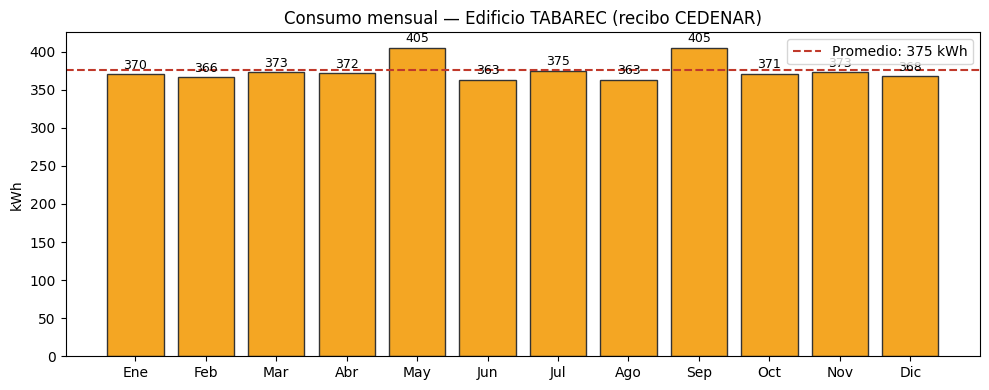

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(df_consumo["mes"], df_consumo["kwh"], color="#f4a623", edgecolor="#333")
ax.axhline(consumo_promedio_kwh, color="#c0392b", linestyle="--", label=f"Promedio: {consumo_promedio_kwh:.0f} kWh")
ax.set_ylabel("kWh")
ax.set_title("Consumo mensual — Edificio TABAREC (recibo CEDENAR)")
ax.legend()
for bar, val in zip(bars, df_consumo["kwh"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3, str(val),
            ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

### Observaciones del consumo

- Consumo **muy estable**: entre 363 y 405 kWh/mes (~11% de variación).
- Picos en **mayo y septiembre** (405 kWh) — posible mayor uso de áreas comunes.
- Es carga **comercial no residencial** (zonas comunes del edificio).
- El ahorro solar se calcula sobre **energía activa** ($883,72/kWh); alumbrado público y contribución son cargos fijos o proporcionales distintos.

> **Pendiente:** confirmar si hay medición de demanda máxima (kW) y horarios de mayor consumo.

---
## Etapa 1b — Incremento por ascensor

**Estado:** ✅ Estimado

| Parámetro | Valor |
|-----------|-------|
| Potencia motor | 7,5 kW (nominal) |
| Pisos | 7 |
| Horario | Lunes a sábado, 7:00 – 18:00 (11 h/día) |
| Domingos | Fuera de servicio (solo standby) |

> El motor **no opera a plena carga** todo el horario. El consumo real depende de viajes, carga y tiempo en reposo.

In [9]:
# --- Parámetros del ascensor ---
ascensor = {
    "potencia_motor_kw": 7.5,
    "pisos": 7,
    "altura_piso_m": 3.0,           # altura típica comercial
    "dias_servicio": ["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb"],
    "hora_inicio": 7,
    "hora_fin": 18,                  # 11 h/día en servicio
    "dias_servicio_mes": 26.1,       # 6/7 × 30,44 días
    "potencia_standby_kw": 0.18,     # reposo con ventilación/iluminación cabina
}

altura_total_m = (ascensor["pisos"] - 1) * ascensor["altura_piso_m"]
horas_servicio_dia = ascensor["hora_fin"] - ascensor["hora_inicio"]

# Energía estimada por viaje (subida con contrapeso, carga media ~40 %)
# Referencia: ISO 25745 / edificios 5–10 pisos → 0,03–0,06 kWh/viaje
KWH_POR_VIAJE = 0.042

def estimar_ascensor(viajes_dia, kwh_viaje=KWH_POR_VIAJE):
    """Estima consumo mensual y anual del ascensor."""
    dias_mes = ascensor["dias_servicio_mes"]

    # Energía en viajes (solo días de servicio)
    kwh_viajes_dia = viajes_dia * kwh_viaje
    kwh_viajes_mes = kwh_viajes_dia * dias_mes

    # Standby en horario de servicio
    kwh_standby_servicio_mes = ascensor["potencia_standby_kw"] * horas_servicio_dia * dias_mes

    # Standby fuera de horario (noches entre semana + domingos)
    horas_noche_semana = (24 - horas_servicio_dia) * dias_mes
    horas_domingo_mes = 4.33 * 24
    kwh_standby_fuera_mes = ascensor["potencia_standby_kw"] * 0.6 * (horas_noche_semana + horas_domingo_mes)

    kwh_mes = kwh_viajes_mes + kwh_standby_servicio_mes + kwh_standby_fuera_mes
    kwh_anual = kwh_mes * 12

    return {
        "viajes_dia": viajes_dia,
        "kwh_viajes_mes": round(kwh_viajes_mes, 1),
        "kwh_standby_mes": round(kwh_standby_servicio_mes + kwh_standby_fuera_mes, 1),
        "kwh_mes": round(kwh_mes, 1),
        "kwh_anual": round(kwh_anual, 0),
    }

# Tres escenarios de tráfico (zonas comunes, edificio 7 pisos)
escenarios = {
    "Bajo (40 viajes/día)": estimar_ascensor(40),
    "Medio (70 viajes/día)": estimar_ascensor(70),
    "Alto (100 viajes/día)": estimar_ascensor(100),
}

df_ascensor = pd.DataFrame(escenarios).T
print(f"Ascensor: {ascensor['potencia_motor_kw']} kW | {ascensor['pisos']} pisos | {altura_total_m:.0f} m recorrido máx.")
print(f"Horario: Lun–Sáb {ascensor['hora_inicio']}:00–{ascensor['hora_fin']}:00 ({horas_servicio_dia} h/día)\n")
print(df_ascensor.to_string())

# Escenario de diseño: tráfico medio
ascensor_estimado = escenarios["Medio (70 viajes/día)"]

Ascensor: 7.5 kW | 7 pisos | 18 m recorrido máx.
Horario: Lun–Sáb 7:00–18:00 (11 h/día)

                       viajes_dia  kwh_viajes_mes  kwh_standby_mes  kwh_mes  kwh_anual
Bajo (40 viajes/día)         40.0            43.8             99.5    143.4     1721.0
Medio (70 viajes/día)        70.0            76.7             99.5    176.3     2115.0
Alto (100 viajes/día)       100.0           109.6             99.5    209.2     2510.0


In [10]:
# --- Demanda total proyectada (base + ascensor) ---
consumo_base_anual = consumo_anual_kwh
consumo_base_mensual = consumo_promedio_kwh

consumo_ascensor_anual = ascensor_estimado["kwh_anual"]
consumo_ascensor_mensual = ascensor_estimado["kwh_mes"]

consumo_total_anual = consumo_base_anual + consumo_ascensor_anual
consumo_total_mensual = consumo_base_mensual + consumo_ascensor_mensual

incremento_pct = (consumo_ascensor_anual / consumo_base_anual) * 100

print("=== Demanda proyectada con ascensor (escenario medio) ===")
print(f"Consumo base (recibo):     {consumo_base_anual:,.0f} kWh/año  ({consumo_base_mensual:.0f} kWh/mes)")
print(f"Ascensor estimado:       + {consumo_ascensor_anual:,.0f} kWh/año  (+{consumo_ascensor_mensual:.0f} kWh/mes)")
print(f"{'—'*50}")
print(f"TOTAL proyectado:          {consumo_total_anual:,.0f} kWh/año  ({consumo_total_mensual:.0f} kWh/mes)")
print(f"Incremento:                +{incremento_pct:.0f} %")
print()
print(f"Costo energía adicional:   ${consumo_ascensor_anual * recibo['cuv_cop_kwh']:,.0f} COP/año")
print(f"Costo energía total:       ${consumo_total_anual * recibo['cuv_cop_kwh']:,.0f} COP/año")

=== Demanda proyectada con ascensor (escenario medio) ===
Consumo base (recibo):     4,504 kWh/año  (375 kWh/mes)
Ascensor estimado:       + 2,115 kWh/año  (+176 kWh/mes)
——————————————————————————————————————————————————
TOTAL proyectado:          6,619 kWh/año  (552 kWh/mes)
Incremento:                +47 %

Costo energía adicional:   $1,869,068 COP/año
Costo energía total:       $5,849,343 COP/año


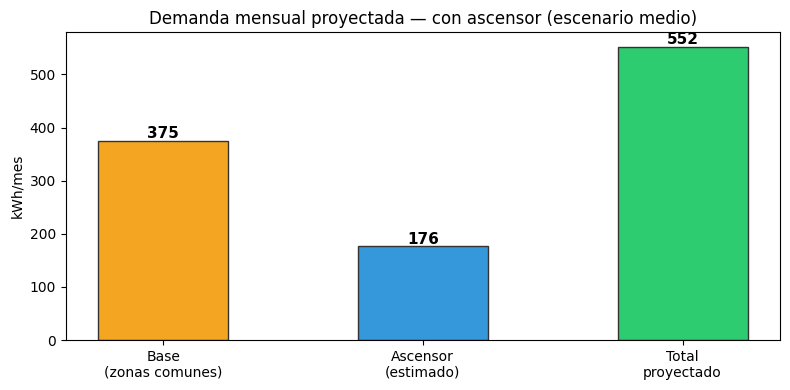

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))

categorias = ["Base\n(zonas comunes)", "Ascensor\n(estimado)", "Total\nproyectado"]
valores = [consumo_base_mensual, consumo_ascensor_mensual, consumo_total_mensual]
colores = ["#f4a623", "#3498db", "#2ecc71"]

bars = ax.bar(categorias, valores, color=colores, edgecolor="#333", width=0.5)
ax.set_ylabel("kWh/mes")
ax.set_title("Demanda mensual proyectada — con ascensor (escenario medio)")
for bar, val in zip(bars, valores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f"{val:.0f}", ha="center", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

### Supuestos del cálculo

1. **7 pisos**, 3 m por piso → 18 m de recorrido útil.
2. **0,042 kWh/viaje** (subida con carga media, contrapeso activo) — rango típico 0,03–0,06.
3. **Standby ~180 W** en reposo (ventilación, iluminación, electrónica).
4. **70 viajes/día** en escenario medio (~10 viajes/hora en horario de servicio).
5. El motor de **7,5 kW** es potencia pico; solo se alcanza en arranques con carga alta.

| Escenario | Viajes/día | kWh/mes | kWh/año | Incremento vs base |
|-----------|------------|---------|---------|-------------------|
| Bajo | 40 | ~143 | ~1 720 | +38 % |
| **Medio** | **70** | **~176** | **~2 115** | **+47 %** |
| Alto | 100 | ~209 | ~2 510 | +56 % |

> Si conocés el número real de viajes/día o la ficha técnica del ascensor, afinamos el estimado.

---
## Etapa 2 — Datos del sitio

**Estado:** ⬜ Parcial — dirección del recibo, falta detalle de instalación.

In [12]:
# --- Sitio de instalación ---
sitio = {
    "nombre": "Edificio TABAREC",
    "direccion": recibo["direccion"],
    "ciudad": "Pasto",
    "departamento": "Nariño",
    "pais": "Colombia",
    "latitud": 1.2136,          # Pasto — verificar en PVGIS
    "longitud": -77.2811,
    "altitud_m": 2527,          # Pasto ~2 527 msnm
    "operador_red": "CEDENAR",
    "tipo_instalacion": None,     # TODO: techo / cubierta / estructura propia
    "orientacion": None,          # TODO: azimut (0° = Norte en hemisferio sur)
    "inclinacion_grados": None,   # TODO
    "sombreado": None,            # TODO: ninguno / parcial
    "area_disponible_m2": None,   # TODO
}

# Irradiación — pendiente consultar PVGIS con coordenadas exactas
irradiacion = {
    "fuente": "Pendiente (PVGIS / IDEAM)",
    "hsp_kwh_m2_dia": None,        # Horas sol pico — estimado Pasto: ~4.5–5.0
    "ghi_anual_kwh_m2": None,
}

print(f"Sitio: {sitio['nombre']}, {sitio['ciudad']} ({sitio['altitud_m']} msnm)")
print(f"Coordenadas: {sitio['latitud']}, {sitio['longitud']}")
print(f"Operador de red: {sitio['operador_red']}")

Sitio: Edificio TABAREC, Pasto (2527 msnm)
Coordenadas: 1.2136, -77.2811
Operador de red: CEDENAR


---
## Etapa 3 — Objetivo del sistema

**Estado:** ⬜ Por definir

In [13]:
objetivo = {
    "tipo_sistema": "On-grid",
    "cobertura_pct": 100,
    "autoconsumo": True,
    "excedentes_red": True,
    "baterias": False,
    "respaldo_emergencia": False,
}

# Demanda de diseño: base + ascensor (escenario medio)
demanda_diseno_kwh = consumo_total_anual

print(f"Sistema: {objetivo['tipo_sistema']}")
print(f"Cobertura objetivo: {objetivo['cobertura_pct']}%")
print(f"Demanda de diseño: {demanda_diseno_kwh:,.0f} kWh/año  (base {consumo_base_anual:,.0f} + ascensor {consumo_ascensor_anual:,.0f})")

Sistema: On-grid
Cobertura objetivo: 100%
Demanda de diseño: 6,619 kWh/año  (base 4,504 + ascensor 2,115)


---
## Etapa 4 — Dimensionamiento (borrador)

Basado en demanda total proyectada **con ascensor**.

In [14]:
PR = 0.80
HSP = None

def dimensionar(consumo_anual_kwh, HSP, potencia_wp, PR=0.80, cobertura=1.0):
    if not HSP:
        return None
    ppico_kw = (consumo_anual_kwh / (HSP * 365 * PR)) * cobertura
    n_modulos = round(ppico_kw * 1000 / potencia_wp)
    return {
        "potencia_pico_kw": round(ppico_kw, 2),
        "n_modulos": n_modulos,
        "potencia_real_kwp": round(n_modulos * potencia_wp / 1000, 2),
    }

HSP_estimado = 4.8
modulo_wp = 550

dim_base = dimensionar(consumo_base_anual, HSP_estimado, modulo_wp, PR, objetivo["cobertura_pct"]/100)
dim_total = dimensionar(demanda_diseno_kwh, HSP_estimado, modulo_wp, PR, objetivo["cobertura_pct"]/100)

print("=== Dimensionamiento preliminar ===")
print(f"(HSP = {HSP_estimado} h/día, módulo {modulo_wp} Wp, PR = {PR})\n")
print(f"{'':20} {'Sin ascensor':>14} {'Con ascensor':>14}")
print(f"{'Demanda (kWh/año)':20} {consumo_base_anual:>14,.0f} {demanda_diseno_kwh:>14,.0f}")
print(f"{'Potencia (kWp)':20} {dim_base['potencia_real_kwp']:>14} {dim_total['potencia_real_kwp']:>14}")
print(f"{'Módulos':20} {dim_base['n_modulos']:>14} {dim_total['n_modulos']:>14}")
print()
print("⚠️  Confirmar HSP con PVGIS antes de dimensionar definitivamente.")

=== Dimensionamiento preliminar ===
(HSP = 4.8 h/día, módulo 550 Wp, PR = 0.8)

                       Sin ascensor   Con ascensor
Demanda (kWh/año)             4,504          6,619
Potencia (kWp)                  3.3           4.95
Módulos                           6              9

⚠️  Confirmar HSP con PVGIS antes de dimensionar definitivamente.


---
## Bitácora de decisiones

| Fecha | Decisión | Fuente |
|-------|----------|--------|
| 2026-06-22 | Inicio del proyecto SFV_TABAREC | — |
| 2026-06-22 | Datos de consumo y tarifa extraídos del recibo CEDENAR Feb/2026 | Recibo físico |
| 2026-06-22 | Sistema propuesto on-grid, 100% cobertura, sin baterías | Hipótesis inicial |
| 2026-06-22 | Ascensor 7.5 kW, 7 pisos, Lun–Sáb 7–18 h → +~2 115 kWh/año (escenario medio) | Estimación técnica |
| 2026-06-22 | HSP = 4.8 h/día como estimación para Pasto | Por confirmar en PVGIS |

---

## Próximos pasos

1. **Sitio:** ¿Dónde se instalarían los paneles? (azotea, cubierta, estructura)
2. **Área disponible** en m²
3. **Consultar PVGIS** para irradiación real en las coordenadas del edificio
4. **Normativa CEDENAR** para conexión de generación distribuida (AGPE)